# Importando as bibliotecas necessárias

In [ ]:
!pip install -q -U google-generativeai

In [1]:
import pandas as pd
import numpy as np
import json
import time
import google.generativeai as genai
from google.colab import userdata
import os
import getpass

In [ ]:
#Coloque a sua chave da API abaixo no lugar de "chave_pai"
genai.configure(api_key="chave_api")

#Alteramos as configurações de seguranças, pois algumas mensagens não são lidas pelo Gemini por causa do conteúdo
safety_settings = [
    {'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'threshold': 'BLOCK_NONE'},
    {'category': 'HARM_CATEGORY_HATE_SPEECH', 'threshold': 'BLOCK_NONE'},
    {'category': 'HARM_CATEGORY_HARASSMENT', 'threshold': 'BLOCK_NONE'},
    {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'threshold': 'BLOCK_NONE'}
]

model = genai.GenerativeModel(
        model_name = 'gemini-1.5-pro',
        safety_settings = safety_settings)

In [2]:
#Conectando o notebook no Colab com o Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Lendo o dataset de mensagens de phishing

In [ ]:
#Lendo o dataset
dataset = pd.read_csv("/content/drive/Shareddrives/Projeto Hackoon/dataset_final_250.csv")

#remove a primeira coluna (índice 0)
dataset = dataset.loc[:, ['text', 'phishing']]

In [ ]:
dataset

,text,phishing
0,Subject: houston trip hi jaideep ! my first ...,0
1,Subject: request submitted : access request fo...,0
2,"Subject: enron ' s new weather system , courte...",0
3,Subject: foreign language lessons fyi ! - - ...,0
4,"Subject: dr . kaminski , thank you for giving...",0
...,...,...
245,<!doctypehtml><html class=font-marketsans lang...,1
246,<html lang=en-US><meta charset=UTF-8><meta con...,1
247,"<!doctypehtml><meta content=""text/html; charse...",1
248,<script language=javascript><!--\ndocument.wri...,1


In [ ]:
dataset['phishing'].value_counts()

,count
phishing,
0,125
1,125


In [ ]:
template_phishingDetector = '''
[Contexto]
Você é um expert em detecção de phishing. Consegue analisar uma mensagem e dizer se é phishing ou uma mensagem legitima. Você analise o conteúdo
da mensagem e consegue dizer se é de origem de um email, ou uma mensagem de SMS, ou uma URL de um site ou HTML de um site. Textos de phishing frequentemente
usam técnicas de engenharia social enganar usuários. Essas técnicas incluem, mas não estão limitadas a:
recompensas falsas, avisos falsos sobre problemas de conta e criação um senso de urgência ou interesse. Falsificar o endereço do remetente e
incorporar links HTML enganosos também são táticas comuns.

Analise a mensagem seguindo as regras abaixo:
1. Identificar qualquer representação falsa de marcas conhecidas.
2. Avaliar a mensagem por características típicas de phishing (como urgência, e premiação). Note que o endereço do destinatário foi trocado por um endereço aleatório falso
3. Examine URLs por anomalias e verifique os links de destino (Não abra links)
4. Examine mensagens suspeitas de SMS e verifique a identidade do remetente e links
5. Inspecione códigos que foram escritos em alguma linguagem de programação por ameaças escondidas e irregularidades (Não execute nenhum código, somente analise)
6. Verifique a segurança e legitimidade dos websites (Não entre no site).
7. Analise o corpo do email por táticas de engenharia social desenhadas para induzir cliques em hyperlinks
8. Forneça uma avaliação abrangente do e-mail, destacando elementos específicos que apoiam sua conclusão. Incluir um detalhado
explicação de quaisquer indicadores de phishing ou legitimidade encontrados no e-mail
9. Classifique qual o tipo da mensagem, se é mensagem de Email, SMS, URL ou WebSite (HTML).
10. Seja cuidadoso com anexos de emails e arquivos de diferentes formatos.
11. Sumarize seus achados e providencia seu veridito final sobre o conteúdo da mensagem, suportado pelas evidências que você reuniu.

[Instruções]
- O formato de saída deve ser JSON na seguinte estrutura (entre chaves):
  - phishing: Um inteiro que indica se o texto é phishing (1) ou legitimo (0)
  - pontuacao_phishing: pontuação de confiança de risco de phishing como um inteiro numa escala de 0 a 10
  - tipo: se é mensagem de Email, SMS, URL ou WebSite (HTML)
  - breve_razao: breve texto da razão do texto ser phishing
  - raciocinio: raciocinio detalhada do porque o texto é phishing. Máximo de 30 palavras

[Tarefa]
Aqui vai uma pergunta. Lembre-se com atenção das instruções e responda se a mensagem é phishing ou não.
[Pergunta]
{pergunta}
[Resposta]
'''

## Execução do modelo

In [ ]:
#Função que executa o modelo e limpa a String resultante
def exec_gemini(texto):
  resposta = model.generate_content(template_phishingDetector.format(pergunta=texto))
  resposta_limpa = resposta.text.replace("```", "").replace("json", "")
  return resposta_limpa

In [ ]:
def obtendo_respostas():
    df_resultados = pd.DataFrame()

    for index, row in dataset.iterrows():
      sucesso = False  # Variável para controle de sucesso
      while not sucesso:
            try:
                print(index)
                mensagem_sus = row["text"]
                print("Mensagem a ser analisada: ", mensagem_sus)

                resposta = exec_gemini(row['text'])
                print("Resposta do modelo: ", resposta)

                # transforma a string resultante em um json
                resposta = json.loads(resposta)

                # transforma o json em um DataFrame
                df_aux = pd.DataFrame(resposta, index=[0])
                df_resultados = pd.concat([df_resultados, df_aux], ignore_index=True)

                sucesso = True  # Se tudo der certo, define sucesso como True
            except Exception as e:
                print(f"Erro na iteração {index}: {e}. Tentando novamente em 40 segundos.")
                time.sleep(60)  # Espera 60 segundos antes de tentar novamente

    return df_resultados

In [ ]:
resultados = obtendo_respostas()

In [ ]:
resultados

,phishing,pontuacao_phishing,tipo,breve_razao,raciocinio
0,0,0,Website (HTML),O código HTML fornecido é de um site benigno.,O código HTML é de um site que oferece dicioná...
1,0,0,WebSite (HTML),O código HTML fornecido representa um site edu...,O código fonte mostra um site educacional sobr...
2,0,0,WebSite (HTML),Página legítima da Central de Ajuda do Prodigy...,O HTML fornecido é uma página da Central de Aj...
3,0,0,WebSite (HTML),O texto fornecido é código HTML de um site com...,O código HTML é de um site que compara diferen...
4,0,0,WebSite (HTML),Página de login da Tesco Mobile,O HTML fornecido é a página de login da Tesco ...
5,0,0,WebSite (HTML),O código fornecido é o código fonte de um site...,O código fornecido parece ser o código fonte d...
6,0,0,WebSite (HTML),Página de verificação do Cloudflare,"A página contém elementos da Cloudflare, um se..."
7,0,0,WebSite (HTML),O código HTML fornecido parece ser um formulár...,O código HTML representa um formulário da web ...
8,0,0,WebSite (HTML),O código fonte fornecido pertence ao site legí...,"O código fonte pertence ao site do LOVOO, cont..."
9,0,0,WebSite (HTML),O código fonte fornecido é parte de um website...,O código é um trecho HTML de um forum sobre hi...


In [ ]:
# Salvando as respostas do modelo
pd.DataFrame.to_csv(resultados, '/content/drive/Shareddrives/Projeto Hackoon/resultados_250.csv')

# Análise dos resultados


In [3]:
df_respostas = pd.read_csv('/content/drive/Shareddrives/Projeto Hackoon/resultados_250.csv')
df_respostas = df_respostas.drop(columns=['Unnamed: 0'])
df_respostas

,phishing_previsto,pontuacao_phishing,tipo,breve_razao,raciocinio
0,0,0,Email,O email parece ser uma conversa legítima sobre...,O email é uma conversa sobre uma oportunidade ...
1,0,0,Email,O email parece ser uma conversa legítima sobre...,O email discute assuntos técnicos e não aprese...
2,0,0,Email,Email profissional sem indicadores de phishing.,"O email discute assuntos de negócios internos,..."
3,0,0,Email,Este email parece ser um aviso legítimo sobre ...,O email não apresenta nenhuma das característi...
4,0,0,Email,O email parece ser uma mensagem genuína sobre ...,O email discute assuntos relacionados ao traba...
...,...,...,...,...,...
245,1,10,WebSite (HTML),Página web falsa de login do eBay projetada pa...,"A página imita o eBay, mas contém um formulári..."
246,1,8,WebSite (HTML),Página suspeita imitando o Cloudflare.,"A página usa um cronômetro, linguagem urgente ..."
247,1,9,WebSite (HTML),Página de login suspeita que imita o ISPsystem...,A página simula uma página de login do ISPsyst...
248,1,10,WebSite (HTML),O código HTML contem um script que redireciona...,O Javascript usa a função 'unescape' para deco...


In [4]:
dataset = pd.read_csv('/content/drive/Shareddrives/Projeto Hackoon/dataset_final_250.csv')
dataset = dataset.drop(columns=['Unnamed: 0', 'Unnamed: 1'])
dataset

,text,phishing
0,Subject: houston trip hi jaideep ! my first ...,0
1,Subject: request submitted : access request fo...,0
2,"Subject: enron ' s new weather system , courte...",0
3,Subject: foreign language lessons fyi ! - - ...,0
4,"Subject: dr . kaminski , thank you for giving...",0
...,...,...
245,<!doctypehtml><html class=font-marketsans lang...,1
246,<html lang=en-US><meta charset=UTF-8><meta con...,1
247,"<!doctypehtml><meta content=""text/html; charse...",1
248,<script language=javascript><!--\ndocument.wri...,1


In [ ]:
print("Quantidade de mensagens consideras legitimas e consideras phishing", df_respostas['phishing_previsto'].value_counts())
print("Porcentagem de mensagens consideradas legitimas e consideras phishing",round(df_respostas['phishing_previsto'].value_counts(normalize=True) * 100, 2))

Quantidade de mensagens consideras legitimas e consideras phishing phishing_previsto
0    137
1    113
Name: count, dtype: int64
Porcentagem de mensagens consideradas legitimas e consideras phishing phishing_previsto
0    54.8
1    45.2
Name: proportion, dtype: float64


### Matriz de confusão

A matriz de confusão nos ajuda a entender como está a distribuição do nosso resultado. Utilizamos essas informação para guiar na geração dos gráficos e analisar especificamente entradas.

In [ ]:
# Imports necessários para análise dos resultados
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, ImageColorGenerator
import pandas as pd
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

In [ ]:
#Construção da matriz de confusão
cf_matrix = confusion_matrix(df_respostas['phishing_previsto'],dataset['phishing'])
cf_matrix

array([[86, 51],
       [39, 74]])

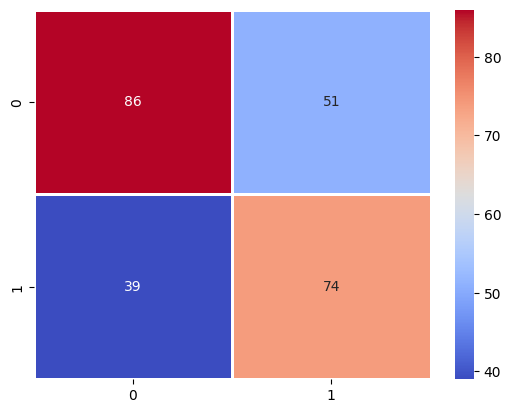

In [ ]:
sns.heatmap(cf_matrix, cmap='coolwarm', annot=True, linewidth=1, fmt='d')
plt.show()

##Calculando métricas

Essas métricas de avaliação nos ajuda a avaliar o desempenho do modelo. Tivemos 64% de acurácia referente a classificação.

In [ ]:
#Métricas de precision, recall e f1-score
print(classification_report(df_respostas['phishing_previsto'],dataset['phishing']))

              precision    recall  f1-score   support

           0       0.69      0.63      0.66       137
           1       0.59      0.65      0.62       113

    accuracy                           0.64       250
   macro avg       0.64      0.64      0.64       250
weighted avg       0.64      0.64      0.64       250



### Distribuição da coluna pontuação phishing
Interessante observar que a API não nos retornou nenhuma resposta na faixa de 3-7, indicando que ele sempre busca indicar que suas escolhas são assertivas.

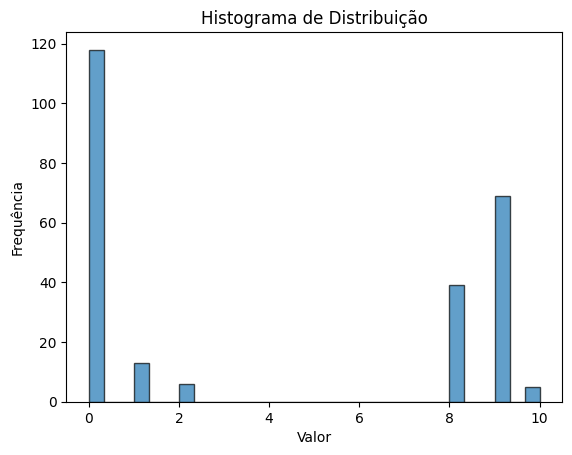

In [ ]:
plt.hist(df_respostas['pontuacao_phishing'], bins=30, edgecolor='k', alpha=0.7)
plt.title('Histograma de Distribuição')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

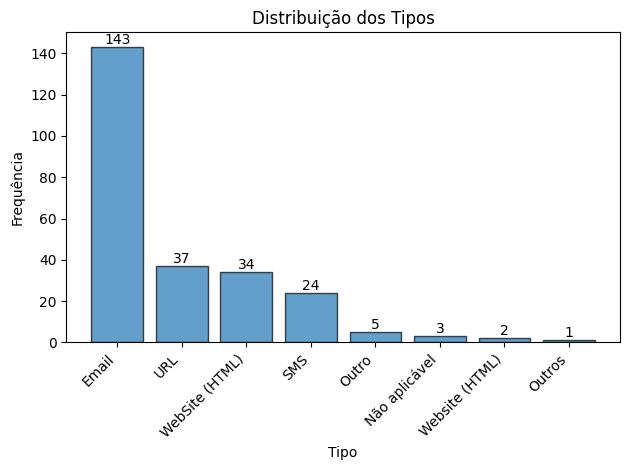

In [ ]:
tipo_counts = df_respostas['tipo'].value_counts()

plt.bar(tipo_counts.index, tipo_counts.values, edgecolor='k', alpha=0.7)
plt.title('Distribuição dos Tipos')
plt.xlabel('Tipo')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Contagem dos tipos
for i, value in enumerate(tipo_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

### Nuvem de palavras
A nuvem de palavras nos ajuda a ter uma ideia de quais são osprincipais temas abordados nos textos presentes do dataset, palavras como "Enron" e "Dynergy" se referem a empresas do ramo de energia, outras palavras presentes na nuvem como "energy" e "power" nos ajuda a entender que há bastante palavras que se referem a utilização de energia. Lembrando, nosso dataset é randomizado, então, há diversos temos e a cardinalidade de temas/palavras é grande.

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993227 sha256=2e2c6b76fc0d73efed1d04a9b5bffb9b76f98b211c823b79e1d1b7168e3bcb58
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


### O código abaixo é usado para verificar em quais línguas as mensagens foram escritas para poder-mos saber qual(is) lista(s) de stopwords vamos utilizar para a criação da nuvem de palavras

In [ ]:
# Carregar o dataset
file_path = '/content/drive/Shareddrives/Projeto Hackoon/dataset_final_250.csv'
df = pd.read_csv(file_path)

# Função para detectar a linguagem, tratando exceções
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'  # Retorna 'unknown' para textos não detectáveis

# Detectar a linguagem das mensagens de texto, tratando exceções
df['language'] = df['text'].apply(detect_language)

# Exibir as linguagens detectadas
print(df[['text', 'language']].head())

                                                text language
0  Subject: houston trip  hi jaideep !  my first ...       en
1  Subject: request submitted : access request fo...       en
2  Subject: enron ' s new weather system , courte...       en
3  Subject: foreign language lessons  fyi !  - - ...       en
4  Subject: dr . kaminski ,  thank you for giving...       en


In [ ]:
df['language'].value_counts()

language
en         223
unknown     10
ca           2
es           2
pt           2
af           1
so           1
no           1
pl           1
nl           1
hr           1
fr           1
tr           1
it           1
tl           1
hu           1
Name: count, dtype: int64

In [ ]:
df_filtrado = df_respostas.join(dataset)
df_filtrado = df_filtrado[df_filtrado['tipo'] == "Email"]
df_filtrado

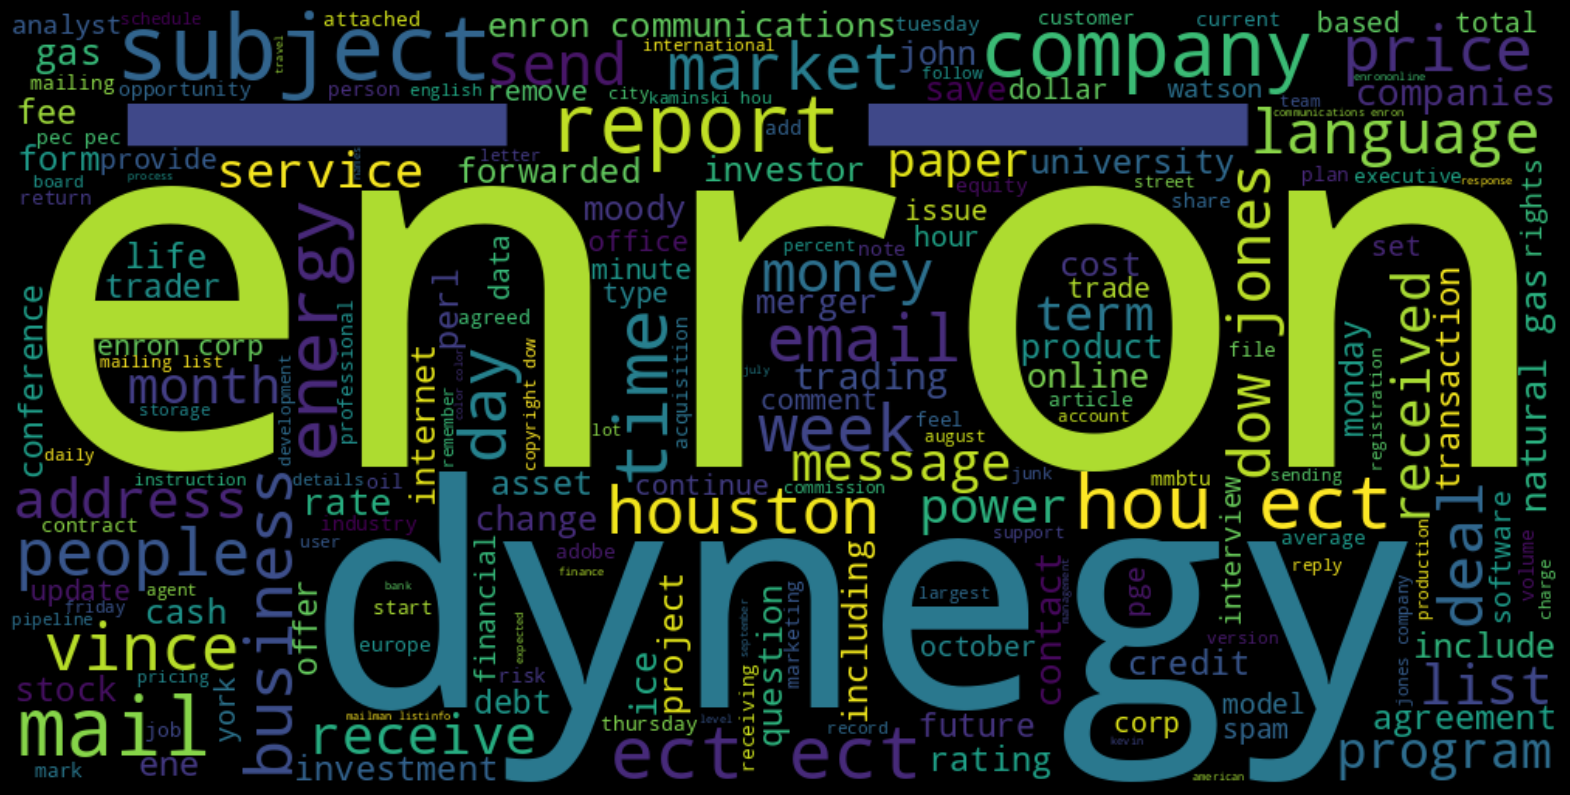

In [ ]:
# Pegando só as mensagens de email
df_filtrado = df_respostas.join(dataset)
df_filtrado = df_filtrado[(df_filtrado['tipo'] == "Email") | (df_filtrado['tipo'] == "SMS")]

texto = ' '.join(df_filtrado['text'].dropna().astype(str))

# Lê stopwords em inglês do arquivo e transforme-as em uma lista
with open('/content/drive/Shareddrives/Projeto Hackoon/stopwords-en.txt', 'r', encoding='utf-8') as file:
    stopwords = file.read().splitlines()

# Inicializa a WordCloud com as stopwords e outras configurações
wordcloud = WordCloud(stopwords=set(stopwords),
                      background_color='black',
                      width=1000,
                      height=500,
                      contour_width=2,
                      contour_color='lightblue')

# Gera a WordCloud a partir do texto
wordcloud.generate(texto)

# Configura e mostra o gráfico da WordCloud
plt.figure(figsize=(20, 15), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
